# Chapter 13. Explainability in Production: RAG, Agents, and Governance

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mohammadi-hadi/hands-on-xai-labs/blob/main/notebooks/ch13-explainability-in-production.ipynb)

Companion notebook for Chapter 13 of *Hands-On Explainable AI*.

**What you'll build:** a small but fully instrumented RAG application over 30 company-policy documents: embeddings written by hand in ten lines (no black-box embedding API), FAISS retrieval with per-document and per-sentence attribution, cited generation with a 0.5B-parameter model, an automated citation-faithfulness audit that catches the citations the model gets wrong, and a six-week explanation-drift monitor that watches the retrieval-attribution distribution shift when production vocabulary changes under your feet.

In [1]:
%%capture
import importlib.util
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    %pip install -q transformers==4.57.* faiss-cpu==1.14.*

In [2]:
import os
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from transformers import logging as hf_logging

hf_logging.set_verbosity_error()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Smoke mode: CI sets BOOK_SMOKE=1 to swap in tiny data budgets
SMOKE = os.environ.get("BOOK_SMOKE") == "1"
DEVICE = os.environ.get("BOOK_DEVICE") or (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

_style = Path("../styles/book.mplstyle")
if _style.exists():
    plt.style.use(_style)
INK, RUST, TEAL, AMBER, ROSE, STONE = (
    "#1A1C1E", "#9A3412", "#0D9488", "#F59E0B", "#E11D48", "#A8A29E"
)

print(f"device={DEVICE} smoke={SMOKE}")

device=mps smoke=False


## 1. A tiny corpus with real production problems

Thirty short policy documents for **Corvid Labs**, a fictional company that sells an analytics dashboard called **Falcon**. We write the corpus by hand because we want its pathologies on purpose. Every real document store has them:

- **near-duplicates**: `doc-4` and `doc-5` say the same thing in different words (a policy page and its FAQ rewrite),
- **stale half-truths**: `doc-2` (an archived PTO policy with the old number), `doc-17` (a rejected SLA draft promising 99.99% uptime), and `doc-21` (superseded launch pricing).

Why it matters: retrieval doesn't know which document is *current*. It only knows which is *similar*. An explainable RAG app has to surface that, not hide it behind a confident answer.

In [3]:
CORPUS = [
    # --- HR policies ---
    ("doc-1", "Corvid Labs full-time employees accrue 25 days of paid time off per calendar year. "
              "Up to 5 unused days roll over into the next year. PTO requests go through the People "
              "portal at least two weeks in advance."),
    ("doc-2", "ARCHIVED (2022). Corvid Labs employees accrue 20 days of paid time off per year, with "
              "no rollover. Kept for reference only; superseded by the current PTO policy."),
    ("doc-3", "Primary caregivers receive 16 weeks of fully paid parental leave; secondary caregivers "
              "receive 8 weeks. Leave can be split into two blocks within the child's first year."),
    ("doc-4", "Employees may work remotely up to 3 days per week. Core collaboration hours are "
              "10:00-15:00 CET regardless of location. Fully remote arrangements require VP approval."),
    ("doc-5", "You can work from home up to 3 days each week. Core hours are 10:00-15:00 CET for "
              "everyone. Permanent remote setups need sign-off from your VP."),
    ("doc-6", "Travel meals are reimbursed up to 40 euros per day with itemized receipts. Submit "
              "expenses within 30 days of the trip through the Finance portal."),
    ("doc-7", "Book all business travel through the TravelDesk portal. Flights under 6 hours are "
              "economy class. Rail is preferred for trips under 500 km."),
    ("doc-8", "All laptops must use full-disk encryption and a screen lock under 5 minutes. "
              "Two-factor authentication is mandatory for every internal system."),
    ("doc-9", "Use a passphrase of at least 16 characters. Passwords rotate every 12 months, and a "
              "company password manager is provided to every employee."),
    ("doc-10", "New hires join a 6-week buddy program. Week 1 covers security training and tooling; "
               "the buddy handles day-to-day questions through week 6."),
    ("doc-11", "The probation period at Corvid Labs is 2 months for all roles. A written evaluation "
               "is shared in week 6 of probation."),
    ("doc-12", "Sick leave is uncapped. A doctor's note is required after 3 consecutive sick days. "
               "Notify your manager before 10:00 on the first day."),
    ("doc-13", "Every employee receives a home-office equipment budget of 1200 euros, refreshed "
               "every 3 years. Purchases go through the IT catalog."),
    ("doc-14", "The annual learning budget is 1500 euros per employee plus 5 paid learning days. "
               "Conference travel counts against the learning budget, not team budgets."),
    # --- Falcon product policies ---
    ("doc-15", "Falcon is Corvid Labs' real-time analytics dashboard. It ingests product events, "
               "builds funnels and retention charts, and ships with a natural-language query bar."),
    ("doc-16", "The Falcon service-level agreement guarantees 99.9% monthly uptime. Each 0.1% below "
               "target earns customers a 10% service credit on that month's invoice."),
    ("doc-17", "DRAFT - never approved. Proposal to market Falcon at 99.99% uptime with unlimited "
               "service credits. Legal review rejected this draft; do not quote it externally."),
    ("doc-18", "Falcon stores raw event data for 90 days and aggregated metrics for 2 years. "
               "Deletion requests are honored within 30 days."),
    ("doc-19", "Falcon Standard support answers within 24 business hours. Premium support answers "
               "within 4 hours, around the clock, and includes a named engineer."),
    ("doc-20", "The Falcon Team plan costs 49 euros per seat per month, billed annually. The "
               "Enterprise plan is quoted per contract and includes SSO and audit logs."),
    ("doc-21", "SUPERSEDED (2021). Falcon launch pricing was 29 euros per seat per month. This page "
               "is retained for billing-history lookups only."),
    ("doc-22", "Falcon exports data as CSV and Parquet. Nightly exports land in the customer's cloud "
               "bucket; on-demand exports are capped at 1 GB."),
    ("doc-23", "SAML single sign-on for Falcon is available on the Enterprise plan only. SCIM "
               "provisioning is included with SSO."),
    ("doc-24", "Annual Falcon subscriptions carry a 30-day money-back guarantee. Monthly plans can "
               "be cancelled anytime and end at the close of the billing cycle."),
    ("doc-25", "Customer data is processed under GDPR and stored in the EU (Frankfurt region). "
               "Corvid Labs never trains models on customer data without written consent."),
    ("doc-26", "During incidents Corvid Labs updates the public status page within 30 minutes. A "
               "written postmortem is published within 5 business days of resolution."),
    ("doc-27", "The subprocessor list is reviewed quarterly and published on the trust page. "
               "Customers are notified 30 days before any new subprocessor is added."),
    ("doc-28", "The Falcon API allows 600 requests per minute per workspace. Bursts up to 900 "
               "requests per minute are tolerated for 60 seconds."),
    ("doc-29", "Employees observe the national holidays of their contract country plus 2 "
               "company-wide days: the Friday after Ascension and December 24."),
    ("doc-30", "Corvid Labs has zero tolerance for harassment. Reports go to people-ops or the "
               "anonymous ethics line; retaliation is itself a violation."),
]
DOCS = dict(CORPUS)
DOC_IDS = [d for d, _ in CORPUS]
print(f"{len(CORPUS)} documents | near-duplicates: doc-4/doc-5 | "
      f"stale half-truths: doc-2, doc-17, doc-21")

30 documents | near-duplicates: doc-4/doc-5 | stale half-truths: doc-2, doc-17, doc-21


## 2. Retrieval with receipts

First, the embedding model, `all-MiniLM-L6-v2`, loaded through plain `transformers`. Most tutorials hide this behind an embedding API; the whole trick is ten lines: run the encoder, average the token vectors that aren't padding, normalize to unit length so inner product equals cosine similarity. Once you've seen it, an "embedding service" stops being magic, which is exactly the mindset this chapter is about.

In [4]:
import faiss
from transformers import AutoModel, AutoTokenizer

EMB_ID = "sentence-transformers/all-MiniLM-L6-v2"
emb_tok = AutoTokenizer.from_pretrained(EMB_ID)
emb_model = AutoModel.from_pretrained(EMB_ID).to(DEVICE).eval()


def embed(texts):
    """Mean-pooled, L2-normalized sentence embeddings; the whole trick in ten lines."""
    enc = emb_tok(texts, padding=True, truncation=True, max_length=256,
                  return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        hidden = emb_model(**enc).last_hidden_state        # (batch, tokens, 384)
    mask = enc["attention_mask"].unsqueeze(-1).float()     # 1 on real tokens, 0 on padding
    pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)  # mean over real tokens
    pooled = torch.nn.functional.normalize(pooled, dim=-1)  # unit length: IP == cosine
    return pooled.cpu().numpy().astype("float32")


doc_vecs = embed([text for _, text in CORPUS])
index = faiss.IndexFlatIP(doc_vecs.shape[1])  # exact inner-product search
index.add(doc_vecs)
print(f"indexed {index.ntotal} docs, dim {doc_vecs.shape[1]}")

'(ProtocolError('Connection aborted.', ConnectionResetError(54, 'Connection reset by peer')), '(Request ID: fdb52d23-3be0-4057-ae24-c208e52bac16)')' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json


Retrying in 1s [Retry 1/5].


indexed 30 docs, dim 384


**Retrieval attribution** is the explanation layer for the retrieval step: for any query, the similarity of *every* document (not just the winners), plus a sentence-level breakdown of the top document. Watch what the receipts expose below. For the first query the user says *vacation*, and the **holiday calendar outranks the PTO policy**, with the archived `doc-2` scoring within a whisker of the current `doc-1`: vocabulary mismatch and staleness, both invisible in a top-1 answer, both obvious in the attribution bars. For the second query the near-duplicates `doc-4`/`doc-5` **split the attribution mass** that a deduplicated corpus would concentrate on one document.

In [5]:
def all_sims(query):
    """Cosine similarity of the query to every document (the full attribution vector)."""
    return doc_vecs @ embed([query])[0]


def retrieve(query, k=3):
    sims, idxs = index.search(embed([query]), k)
    return [(DOC_IDS[i], float(s), DOCS[DOC_IDS[i]]) for s, i in zip(sims[0], idxs[0])]


def sentence_attribution(query, doc_id):
    """Per-sentence similarity inside one document: which sentence did the work?"""
    sents = re.split(r"(?<=[.!?])\s+", DOCS[doc_id])
    sims = embed(sents) @ embed([query])[0]
    return sorted(zip(sims.tolist(), sents), reverse=True)


for demo_q in ["How many days of paid vacation do I get?",
               "Can I work from home this week?"]:
    print(f"Q: {demo_q}")
    for doc_id, score, _ in retrieve(demo_q, k=4):
        bar = "#" * int(score * 40)
        print(f"   {doc_id:>7s}  {score:.3f}  {bar}")
    top_id = retrieve(demo_q, k=1)[0][0]
    print(f"   sentence-level attribution inside {top_id}:")
    for s, sent in sentence_attribution(demo_q, top_id):
        print(f"     {s:.3f}  {sent}")
    print()

Q: How many days of paid vacation do I get?
    doc-29  0.523  ####################
     doc-6  0.483  ###################
     doc-2  0.456  ##################
     doc-1  0.428  #################
   sentence-level attribution inside doc-29:
     0.523  Employees observe the national holidays of their contract country plus 2 company-wide days: the Friday after Ascension and December 24.

Q: Can I work from home this week?
     doc-5  0.613  ########################
     doc-4  0.486  ###################
    doc-10  0.299  ###########
    doc-29  0.289  ###########
   sentence-level attribution inside doc-5:
     0.812  You can work from home up to 3 days each week.
     0.336  Core hours are 10:00-15:00 CET for everyone.
     0.144  Permanent remote setups need sign-off from your VP.



## 3. Cited generation with a 0.5B model

`Qwen2.5-0.5B-Instruct` answers questions from the top-3 retrieved documents and is instructed to cite `[doc-N]` after each claim. We use a deliberately small model on CPU: citation failures at this scale are not a bug in the lab, they are the *subject* of the lab. Greedy decoding keeps runs reproducible.

Three of the eight questions aim straight at the corpus traps (archived PTO number, rejected SLA draft, superseded pricing) so we can watch what the model does when retrieval hands it a half-truth next to the truth.

In [6]:
from transformers import AutoModelForCausalLM

GEN_ID = "Qwen/Qwen2.5-0.5B-Instruct"
gen_tok = AutoTokenizer.from_pretrained(GEN_ID)
gen_model = AutoModelForCausalLM.from_pretrained(GEN_ID, dtype=torch.float32).eval()
# greedy decoding: drop the sampling defaults so generate() doesn't warn
gen_model.generation_config.temperature = None
gen_model.generation_config.top_p = None
gen_model.generation_config.top_k = None

SYSTEM = (
    "You answer questions about Corvid Labs policies using ONLY the documents provided. "
    "Write one or two full sentences that state the answer, and end each sentence with the "
    "id of the document that supports it, in brackets. "
    "Example format: The travel meal budget is 40 euros per day [doc-6]. "
    "If the documents do not contain the answer, say you cannot answer."
)


def generate_answer(question, k=3, max_new_tokens=80):
    hits = retrieve(question, k)
    context = "\n".join(f"[{d}] {t}" for d, _, t in hits)
    msgs = [{"role": "system", "content": SYSTEM},
            {"role": "user", "content": f"{context}\n\nQuestion: {question}"}]
    enc = gen_tok.apply_chat_template(msgs, add_generation_prompt=True,
                                      return_dict=True, return_tensors="pt")
    with torch.no_grad():
        out = gen_model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=False)
    answer = gen_tok.decode(out[0, enc["input_ids"].shape[1]:], skip_special_tokens=True)
    return answer.strip(), hits

In [7]:
QUESTIONS = [
    {"q": "How many days of paid time off do full-time employees get per year?",
     "gold_doc": "doc-1", "gold_re": r"\b25\b", "trap": "doc-2 says 20 (archived)"},
    {"q": "What monthly uptime does the Falcon SLA guarantee?",
     "gold_doc": "doc-16", "gold_re": r"99\.9\b", "trap": "doc-17 says 99.99 (rejected draft)"},
    {"q": "How many weeks of parental leave does a primary caregiver receive?",
     "gold_doc": "doc-3", "gold_re": r"\b16\b", "trap": None},
    {"q": "How large is the home-office equipment budget?",
     "gold_doc": "doc-13", "gold_re": r"\b1200\b", "trap": None},
    {"q": "How long does Falcon keep raw event data?",
     "gold_doc": "doc-18", "gold_re": r"\b90\b", "trap": None},
    {"q": "How fast does Falcon Premium support respond?",
     "gold_doc": "doc-19", "gold_re": r"\b4\b", "trap": None},
    {"q": "How much does the Falcon Team plan cost per seat per month?",
     "gold_doc": "doc-20", "gold_re": r"\b49\b", "trap": "doc-21 says 29 (superseded)"},
    {"q": "How many days per week can employees work remotely?",
     "gold_doc": "doc-4", "gold_re": r"\b3\b", "trap": "doc-5 is a near-duplicate"},
]

MAXTOK_CITE = 48 if SMOKE else 80
run_questions = [QUESTIONS[i] for i in ((0, 1, 6) if SMOKE else range(len(QUESTIONS)))]

results = []
for item in run_questions:
    answer, hits = generate_answer(item["q"], max_new_tokens=MAXTOK_CITE)
    results.append({**item, "answer": answer, "hits": hits})
    print(f"Q: {item['q']}")
    print(f"   retrieved: {[h[0] for h in hits]}")
    print(f"A: {answer}\n")

Q: How many days of paid time off do full-time employees get per year?
   retrieved: ['doc-2', 'doc-1', 'doc-29']
A: The full-time employees accrue 25 days of paid time off per calendar year.



Q: What monthly uptime does the Falcon SLA guarantee?
   retrieved: ['doc-16', 'doc-24', 'doc-19']
A: The Falcon service-level agreement guarantees 99.9% monthly uptime.



Q: How many weeks of parental leave does a primary caregiver receive?
   retrieved: ['doc-3', 'doc-2', 'doc-1']
A: The primary caregivers receive 16 weeks of fully paid parental leave.



Q: How large is the home-office equipment budget?
   retrieved: ['doc-13', 'doc-14', 'doc-20']
A: The home-office equipment budget is 1200 euros per day [doc-6].



Q: How long does Falcon keep raw event data?
   retrieved: ['doc-18', 'doc-22', 'doc-28']
A: The Falcon stores raw event data for 90 days.



Q: How fast does Falcon Premium support respond?
   retrieved: ['doc-19', 'doc-28', 'doc-16']
A: Falcon Premium support responds within 4 hours, around the clock, and includes a named engineer.



Q: How much does the Falcon Team plan cost per seat per month?
   retrieved: ['doc-20', 'doc-21', 'doc-16']
A: The Falcon Team plan costs 49 euros per seat per month [doc-20].



Q: How many days per week can employees work remotely?
   retrieved: ['doc-4', 'doc-5', 'doc-29']
A: The travel meal budget is 40 euros per day [doc-6]. If the documents do not contain the answer, say you cannot answer.



## 4. Citation faithfulness audit

A citation marker is typography, not evidence. The opening claim of this chapter (*your RAG app cites a source it never used*) is testable, so let's test it. For every citation the model emitted we ask two questions:

1. **Was the cited document even in the context?** A `[doc-N]` pointing outside the retrieved top-3 is a hallucinated pointer, full stop.
2. **Does the cited document lexically support the answer?** We use a transparent screening heuristic: the fraction of the answer's content words that appear in the cited document, supported if ≥ 0.5. Production systems upgrade this to an NLI entailment model; the audit *structure* stays identical.

We also run the check in reverse: a context document that heavily overlaps the answer but was never cited is **uncited-but-used**. Call it silent evidence, the mirror-image failure.

In [8]:
CITE_RE = re.compile(r"\[?doc-(\d+)\]?")
STOP = set(
    "a an the of for per to in on at and or is are do does did how many much what which who "
    "with only you your we our it its this that these those according information provided "
    "document documents answer question corvid labs be can may will not no yes as by from".split()
)


def content_words(text):
    toks = re.findall(r"\d+(?:[.,]\d+)?|[a-z]+", text.lower())
    return {t for t in toks if t not in STOP and (len(t) > 2 or any(c.isdigit() for c in t))}


def overlap(answer, doc_text):
    aw = content_words(answer)
    return len(aw & content_words(doc_text)) / len(aw) if aw else 0.0


SUPPORT_T = 0.5   # citation counts as supported at >= 50% content-word overlap
USED_T = 0.5      # uncited context doc counts as 'used' at the same bar

audit_rows = []
for r in results:
    cited = {f"doc-{n}" for n in CITE_RE.findall(r["answer"])}
    clean = CITE_RE.sub("", r["answer"])
    clean_norm = re.sub(r"(?<=\d)[.,](?=\d{3}\b)", "", clean)  # 1,200 -> 1200
    context_ids = [h[0] for h in r["hits"]]
    r["correct"] = bool(re.search(r["gold_re"], clean_norm, re.I))
    for c in sorted(cited):
        if c not in context_ids:
            cat, ov = "cited-unsupported", np.nan
            why = "cites a doc that was never retrieved"
        else:
            ov = overlap(clean, DOCS[c])
            cat = "cited-and-supported" if ov >= SUPPORT_T else "cited-unsupported"
            why = f"overlap={ov:.2f}"
        audit_rows.append({"question": r["q"][:48], "doc": c, "category": cat,
                           "overlap": ov, "note": why})
    for d in context_ids:
        if d not in cited and overlap(clean, DOCS[d]) >= USED_T:
            audit_rows.append({"question": r["q"][:48], "doc": d,
                               "category": "uncited-but-used",
                               "overlap": overlap(clean, DOCS[d]),
                               "note": "silent evidence, used, never cited"})

audit = pd.DataFrame(audit_rows)
counts = audit["category"].value_counts().reindex(
    ["cited-and-supported", "cited-unsupported", "uncited-but-used"], fill_value=0)
n_cited = counts["cited-and-supported"] + counts["cited-unsupported"]
precision = counts["cited-and-supported"] / n_cited if n_cited else float("nan")
accuracy = np.mean([r["correct"] for r in results])

print(f"questions: {len(results)} | answer accuracy: {accuracy:.2f}")
print(f"citations emitted: {n_cited} | citation precision: {precision:.2f}")
print(counts.to_string())
failures = audit[audit["category"] != "cited-and-supported"]
print("\n--- failure table ---")
print(failures.to_string(index=False))

questions: 8 | answer accuracy: 0.88
citations emitted: 3 | citation precision: 0.33
category
cited-and-supported    1
cited-unsupported      2
uncited-but-used       8

--- failure table ---
                                        question    doc          category  overlap                                 note
How many days of paid time off do full-time empl  doc-2  uncited-but-used 0.700000   silent evidence, used, never cited
How many days of paid time off do full-time empl  doc-1  uncited-but-used 1.000000   silent evidence, used, never cited
What monthly uptime does the Falcon SLA guarante doc-16  uncited-but-used 1.000000   silent evidence, used, never cited
How many weeks of parental leave does a primary   doc-3  uncited-but-used 1.000000   silent evidence, used, never cited
  How large is the home-office equipment budget?  doc-6 cited-unsupported      NaN cites a doc that was never retrieved
  How large is the home-office equipment budget? doc-13  uncited-but-used 0.857143   sil

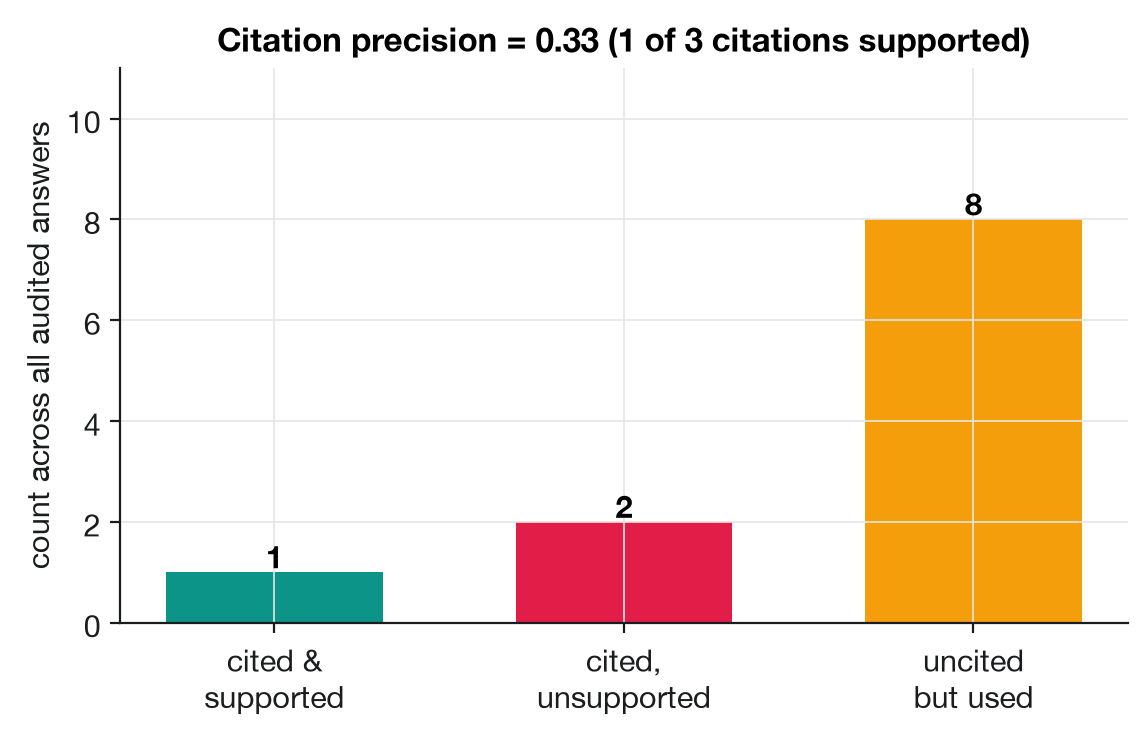

In [9]:
#| label: fig-citation-precision
#| fig-cap: "Citation audit of a 0.5B RAG app: how many citations are actually backed by the cited document, and how much evidence is used silently."
#| fig-alt: "Bar chart of a citation audit for a small RAG app: the share of citations backed by the cited document and the share of evidence used without citation."
fig, ax = plt.subplots(figsize=(6.5, 3.6))
labels = ["cited &\nsupported", "cited,\nunsupported", "uncited\nbut used"]
colors = [TEAL, ROSE, AMBER]
bars = ax.bar(labels, counts.values, color=colors, width=0.62)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.08, str(int(v)),
            ha="center", fontweight="bold")
ax.set_ylabel("count across all audited answers")
ax.set_ylim(0, max(counts.values) * 1.25 + 1)
ax.set_title(f"Citation precision = {precision:.2f} "
             f"({int(counts['cited-and-supported'])} of {int(n_cited)} citations supported)")
plt.show()

Keep the failures. They are better than the ones we planned for. In the run stored here, the 0.5B model produced a citation in only 3 of 8 answers, and two of those point at `doc-6`, the travel-meal document from the **format example in the system prompt**, which was never retrieved for either question. The model didn't ground its citations; it pattern-matched the example. Meanwhile the reverse check finds the real evidence used *silently* in nearly every answer. A citation UI without an audit behind it would render all of this as tidy, trustworthy-looking footnotes: a *trust prop*, not an explanation. The ~30-line audit above, run on every answer, is the production posture this chapter argues for.

## 5. Explanation drift: monitoring the monitor

Production breaks slowly, then suddenly. We simulate six weeks of user queries. In week 4, marketing renames the product. Users start saying **Kestrel** while every indexed document still says **Falcon** (half the users adopt the new name in week 4, all of them from week 5). HR queries are unaffected. Each week's queries also get small phrasing variations, so weeks 1–3 show the monitor's natural noise floor.

We track two weekly signals:

- **answer accuracy** against gold key-phrases (the metric everyone dashboards), and
- **Jensen–Shannon divergence of the retrieval-attribution distribution** vs. the week-1 baseline, the *explanation* signal. Each query's attribution is a softmax over all 30 document similarities; we average per week and compare distributions.

The question that matters for operations: does the explanation signal move **before** the accuracy metric, with it, or not at all?

In [10]:
def js_divergence(p, q):
    """Jensen-Shannon divergence in bits (0 = identical, 1 = disjoint)."""
    p, q = np.asarray(p), np.asarray(q)
    m = (p + q) / 2

    def kl(a, b):
        return float(np.sum(np.where(a > 0, a * np.log2(a / b), 0.0)))

    return 0.5 * kl(p, m) + 0.5 * kl(q, m)


def attribution_dist(query, tau=0.1):
    """Softmax over all doc similarities: where retrieval 'looked' for this query."""
    s = all_sims(query) / tau
    e = np.exp(s - s.max())
    return e / e.sum()


DRIFT_POOL = [
    {"q": "How long does Falcon keep raw event data?",          "gold_doc": "doc-18", "gold_re": r"\b90\b",   "product": True},
    {"q": "Which export formats does Falcon support?",          "gold_doc": "doc-22", "gold_re": r"parquet",   "product": True},
    {"q": "Which Falcon plan includes SAML single sign-on?",    "gold_doc": "doc-23", "gold_re": r"enterprise", "product": True},
    {"q": "What is the Falcon API rate limit per workspace?",   "gold_doc": "doc-28", "gold_re": r"\b600\b",  "product": True},
    {"q": "What does the Falcon Team plan cost per seat?",      "gold_doc": "doc-20", "gold_re": r"\b49\b",   "product": True},
    {"q": "How many weeks of parental leave does a primary caregiver receive?",
     "gold_doc": "doc-3", "gold_re": r"\b16\b", "product": False},
    {"q": "How large is the home-office equipment budget?",     "gold_doc": "doc-13", "gold_re": r"\b1200\b", "product": False},
    {"q": "After how many consecutive sick days is a doctor's note required?",
     "gold_doc": "doc-12", "gold_re": r"\b3\b", "product": False},
]

WEEKS = range(1, 7)
RENAME_P = {1: 0.0, 2: 0.0, 3: 0.0, 4: 0.5, 5: 1.0, 6: 1.0}  # Kestrel adoption
PREFIXES = ["", "Quick question: ", "Hi - ", "Need this for a customer: ", "Please confirm: "]
MAXTOK_DRIFT = 24 if SMOKE else 40
pool = [DRIFT_POOL[i] for i in ((0, 4, 5) if SMOKE else range(len(DRIFT_POOL)))]

weekly_rows, base_dist = [], None
for week in WEEKS:
    rng = random.Random(SEED + week)
    dists, n_correct, n_gold_hit = [], 0, 0
    for item in pool:
        q = item["q"]
        if item["product"] and rng.random() < RENAME_P[week]:
            q = q.replace("Falcon", "Kestrel")
        q = rng.choice(PREFIXES) + q
        dists.append(attribution_dist(q))
        answer, hits = generate_answer(q, max_new_tokens=MAXTOK_DRIFT)
        clean = re.sub(r"(?<=\d)[.,](?=\d{3}\b)", "", CITE_RE.sub("", answer))
        n_correct += bool(re.search(item["gold_re"], clean, re.I))
        n_gold_hit += item["gold_doc"] in [h[0] for h in hits]
    week_dist = np.mean(dists, axis=0)
    if base_dist is None:
        base_dist = week_dist
    weekly_rows.append({"week": week,
                        "accuracy": n_correct / len(pool),
                        "gold_in_top3": n_gold_hit / len(pool),
                        "js_vs_week1": js_divergence(base_dist, week_dist)})

weekly = pd.DataFrame(weekly_rows)
print(weekly.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

 week  accuracy  gold_in_top3  js_vs_week1
    1    0.8750        1.0000       0.0000
    2    1.0000        1.0000       0.0004
    3    1.0000        1.0000       0.0004
    4    0.8750        1.0000       0.0040
    5    0.7500        1.0000       0.0167
    6    0.7500        1.0000       0.0187


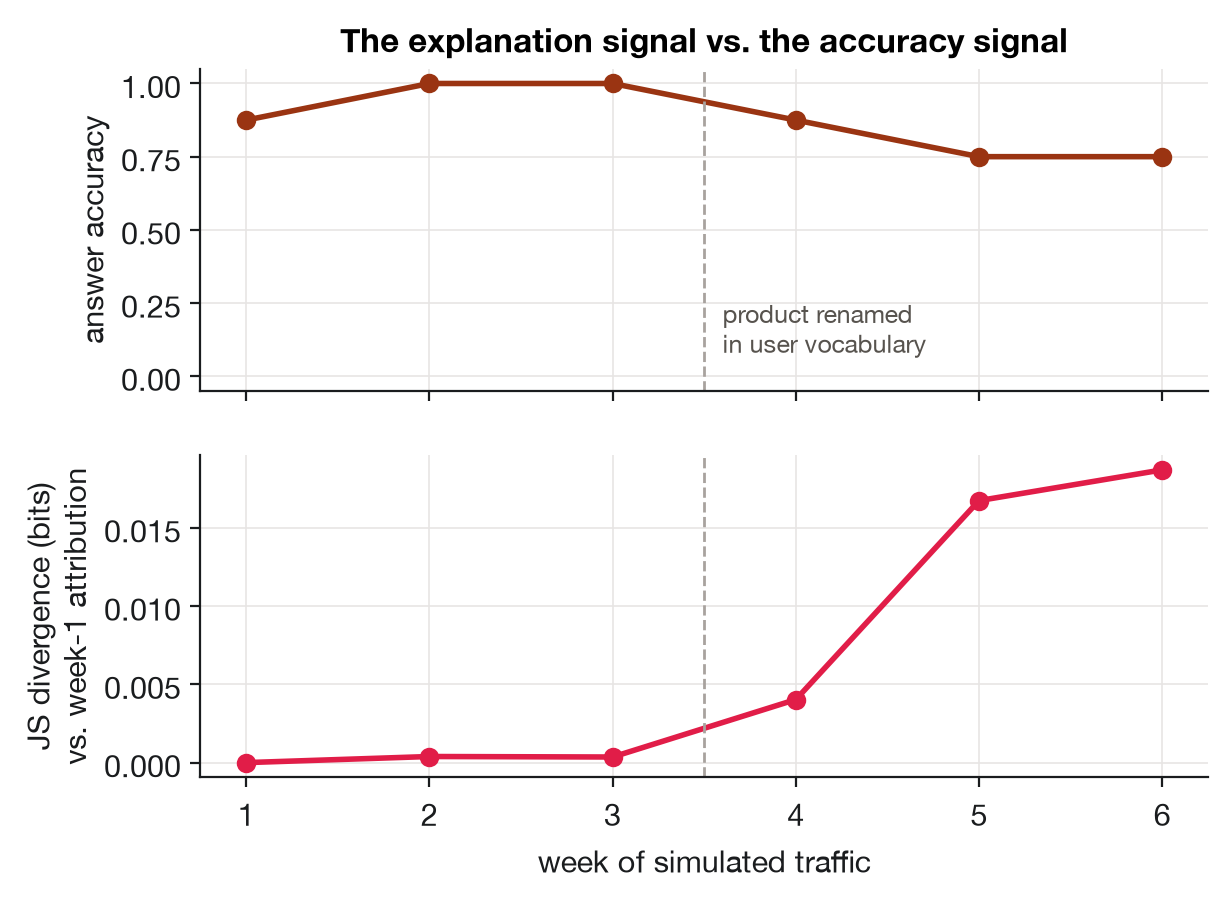

In [11]:
#| label: fig-drift-monitor
#| fig-cap: "Six weeks of simulated production traffic: answer accuracy (top) and Jensen–Shannon divergence of the retrieval-attribution distribution vs. the week-1 baseline (bottom); the product is renamed in users' vocabulary from week 4."
#| fig-alt: "Two stacked time series over six weeks of simulated traffic: answer accuracy stays flat on top while the Jensen-Shannon divergence of the attribution distribution rises from week 4 below."
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6.5, 4.6), sharex=True)

ax1.plot(weekly["week"], weekly["accuracy"], color=RUST, marker="o", linewidth=2)
ax1.set_ylabel("answer accuracy")
ax1.set_ylim(-0.05, 1.05)

ax2.plot(weekly["week"], weekly["js_vs_week1"], color=ROSE, marker="o", linewidth=2)
ax2.set_ylabel("JS divergence (bits)\nvs. week-1 attribution")
ax2.set_xlabel("week of simulated traffic")
ax2.set_xticks(list(WEEKS))

for ax in (ax1, ax2):
    ax.axvline(3.5, color=STONE, linestyle="--", linewidth=1)
GRAPHITE = "#57534E"  # secondary text
ax1.text(3.6, 0.08, "product renamed\nin user vocabulary", color=GRAPHITE, fontsize=9)
ax1.set_title("The explanation signal vs. the accuracy signal")
plt.show()

Read the two panels together. The bottom line is computed from *retrieval attributions alone*: no labels, no gold answers, no human review. The top line needs labeled gold answers, which in real production arrive late (support tickets) or never. In the run stored here, the divergence signal stepped far above its weeks-1–3 noise floor the moment the rename landed, while retrieval itself still found the gold document every time (`gold_in_top3` stayed at 1.0) and accuracy sagged only modestly. The explanation moved *before* the failure became obvious in the outcome metric. That asymmetry is the operational argument: **the explanation layer doubles as your cheapest monitor**, because attribution distributions are computable on 100% of traffic at zero labeling cost.

What to log per request in an explainable-by-design RAG app, which is also the evidence trail the EU AI Act's logging and transparency articles ask high-risk deployers to keep (see the chapter's compliance-matrix figure):

1. query + timestamp,
2. full retrieval attribution vector (not just top-k ids),
3. generated answer + parsed citations,
4. citation-audit verdict per citation,
5. rolling JS divergence of attributions vs. a pinned baseline.

## Now try it on your own data

Point the pipeline at a folder of your own `.txt` files (meeting notes, wiki exports, product docs) and re-run the citation audit. Everything above is reusable: `embed`, `retrieve`, `generate_answer`, and the audit only assume a list of `(doc_id, text)` pairs.

Things worth trying once it runs: lower `SUPPORT_T` and watch precision inflate (a dishonest dashboard in one line); swap the overlap heuristic for an NLI model such as `roberta-large-mnli`; and check whether *your* corpus has a `doc-2`, an archived page shadowing the current one.

In [12]:
# --- Exercise scaffold: audit YOUR documents -------------------------------
MY_DOCS_DIR = Path("my_docs")  # TODO: folder of .txt files, one document each
MY_QUESTIONS = [
    # TODO: 3-5 questions your corpus should answer, e.g.:
    # "What is our refund window?",
]

if MY_DOCS_DIR.exists() and MY_QUESTIONS:
    my_corpus = [(f"doc-{i + 1}", p.read_text()[:1000])
                 for i, p in enumerate(sorted(MY_DOCS_DIR.glob("*.txt")))]
    CORPUS, DOCS, DOC_IDS = my_corpus, dict(my_corpus), [d for d, _ in my_corpus]
    doc_vecs = embed([t for _, t in CORPUS])
    index = faiss.IndexFlatIP(doc_vecs.shape[1])
    index.add(doc_vecs)
    for q in MY_QUESTIONS:
        answer, hits = generate_answer(q)
        cited = {f"doc-{n}" for n in CITE_RE.findall(answer)}
        print(f"Q: {q}\nA: {answer}")
        for c in sorted(cited):
            ok = c in DOCS and overlap(CITE_RE.sub("", answer), DOCS[c]) >= SUPPORT_T
            print(f"   {c}: {'supported' if ok else 'UNSUPPORTED'}")
        # TODO: also flag uncited-but-used docs, as in Section 4
        print()
else:
    print(f"Create {MY_DOCS_DIR}/ with .txt files and add MY_QUESTIONS to run the audit.")

Create my_docs/ with .txt files and add MY_QUESTIONS to run the audit.
